In [1]:
import sys
from pathlib import Path

# add the directory that contains `package/`
sys.path.insert(0, str(Path("..").resolve()))
sys.path

['/Users/selin/PycharmProjects/InsDelGLM',
 '/Users/selin/PycharmProjects/InsDelGLM',
 '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev',
 '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/jupyter_debug',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python311.zip',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/lib-dynload',
 '',
 '/Users/selin/PycharmProjects/InsDelGLM/.venv/lib/python3.11/site-packages']

In [2]:
import torch
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from collections import Counter
from helpers.seq_logo import DNALandscape
from helpers.conf_matrix import plot_evaluation_results

from modules.dna_tokenizer import DNATokenizer
from modules.masked_cnn import DNACNNForMaskedLM

# --- SETUP ---
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

Using device:  mps


In [3]:

# Load Tokenizer & Model
model_path = "../model/CNN_baseline_100k_1e-4"
tokenizer = DNATokenizer(deletion_token=True)
model = DNACNNForMaskedLM.from_pretrained(model_path)
model.to(device)
model.eval()

# Load Data
test_df = pd.read_parquet("../data/simulated/baseline_test.parquet")
print(f"Loaded {len(test_df)} test sequences.")

# Load Motifs
with open("../data/simulated/motifs.txt", "r") as f:
    motifs = [line.strip() for line in f.readlines()]
MOTIF_A = motifs[0]
MOTIF_B = motifs[1]
print(f"Ground Truth Motifs:\nMotif A: {MOTIF_A}\nMotif B: {MOTIF_B}")
# --- DATA "BASELINES" (real baseline is Panther_baseline) ---
all_tokens = []
for seq in test_df["sequences"]:
    all_tokens.extend(list(seq))

counts = Counter(all_tokens)
total_tokens = sum(counts.values())

print("Token Distribution:")
for token, count in counts.items():
    print(f"{token}: {count / total_tokens:.2%}")

random_baseline = 1 / len(counts)
most_common_token, most_common_count = counts.most_common(1)[0]
majority_baseline = most_common_count / total_tokens

Loaded 20000 test sequences.
Ground Truth Motifs:
Motif A: GCGA
Motif B: CCAGT
Token Distribution:
A: 24.57%
T: 22.88%
G: 26.24%
C: 26.30%


In [4]:
print(f"\n--- Baselines ---")
print(f"Random Guess (1/{len(counts)}): {random_baseline:.2%}")
print(f"Majority Class (Always predict '{most_common_token}'): {majority_baseline:.2%}")


def precompute_motif_metadata(df, motif_map):
    """
    Scans the dataset ONCE and saves start/end indices for all motifs.
    """
    df_meta = df.copy()

    print("Pre-computing motif positions...")
    for name, seq in motif_map.items():
        # Find start index (-1 if not found)
        df_meta[f'{name}_start'] = df_meta['sequences'].str.find(seq)

        # Calculate end index
        df_meta[f'{name}_end'] = df_meta.apply(
            lambda x: x[f'{name}_start'] + len(seq) if x[f'{name}_start'] != -1 else -1,
            axis=1
        )

    return df_meta


--- Baselines ---
Random Guess (1/4): 25.00%
Majority Class (Always predict 'C'): 26.30%


In [5]:

# --- EXECUTE ---
motif_map = {
    "Motif_A": MOTIF_A,
    "Motif_B": MOTIF_B
}

test_df_enriched = precompute_motif_metadata(test_df, motif_map)
print("Metadata computed. Sample:")
test_df_enriched[[col for col in test_df_enriched.columns if 'start' in col]].head()
test_df_enriched
print("mask_token_id:", tokenizer.mask_token_id)
print("vocab_size:", model.config.vocab_size)


def evaluate_and_collect_stats(model, tokenizer, test_sequences, batch_size=16):
    model.eval()

    # Storage for all masked instances
    all_preds = []
    all_labels = []

    class TestDataset(Dataset):
        def __init__(self, seqs): self.seqs = seqs

        def __len__(self): return len(self.seqs)

        def __getitem__(self, i): return self.seqs[i]

    dataloader = DataLoader(TestDataset(test_sequences), batch_size=batch_size)

    print("Running evaluation with stats collection...")
    with torch.no_grad():
        for batch_seqs in tqdm(dataloader):
            encoded = tokenizer(batch_seqs, return_tensors="pt", padding="max_length", max_length=512)
            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)
            labels = input_ids.clone()

            # --- MASKING STRATEGY ---
            # Nucleotide IDs are 1–4; exclude PAD (0) and special tokens (>=5)
            rand = torch.rand(input_ids.shape).to(device)
            mask_indices = (
                    (rand < 0.15)
                    & (input_ids > 0)  # exclude PAD
                    & (input_ids < model.config.mask_token_id)  # exclude MASK / CLS / SEP
                    & (attention_mask == 1)
            )

            input_ids[mask_indices] = tokenizer.mask_token_id

            # Predict
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            predictions = torch.argmax(outputs.logits, dim=-1)

            # --- COLLECT DATA ---
            # We only care about the positions we actually masked
            if mask_indices.sum() > 0:
                masked_p = predictions[mask_indices].cpu().numpy()
                masked_l = labels[mask_indices].cpu().numpy()

                all_preds.extend(masked_p)
                all_labels.extend(masked_l)

    return np.array(all_labels), np.array(all_preds)

Pre-computing motif positions...
Metadata computed. Sample:
mask_token_id: 6
vocab_size: 8


In [6]:
# --- EXECUTE COLLECTION ---
true_ids, pred_ids = evaluate_and_collect_stats(model, tokenizer, test_df["sequences"].tolist())

# Calculate Accuracy manually from the lists
acc = (true_ids == pred_ids).mean()
print(f"\nTest Set Masked Accuracy: {acc:.2%}")

Running evaluation with stats collection...


100%|██████████| 1250/1250 [00:05<00:00, 223.43it/s]


Test Set Masked Accuracy: 24.07%


/Users/selin/PycharmProjects/InsDelGLM/helpers/conf_matrix.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts_ordered, palette="viridis")


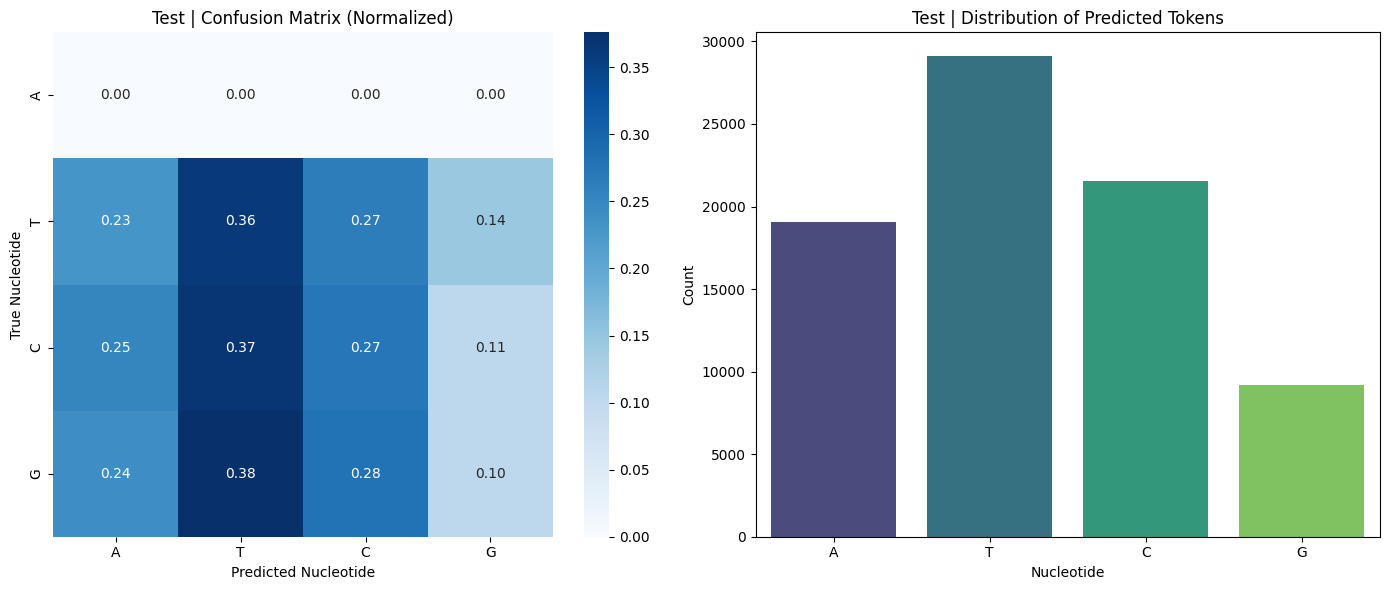

In [7]:
plot_evaluation_results(
    true_ids,
    pred_ids,
    tokenizer,
    dataset_name="Test"
)

In [8]:
# from matplotlib import font_manager
#
# for font in font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
#     print(font_manager.FontProperties(fname=font).get_name())


In [9]:
# Initialize (Pass model once). For font, you can just use the default in the helper.
viz = DNALandscape(model, tokenizer, seq_len=35, font="Arial Rounded MT Bold", use_ic=True)

# aggregated per position
viz.generate_aggregated_gif(test_df_enriched, "Motif_A", MOTIF_A, filename="Motif_A_scan.gif", fps=2)
viz.generate_aggregated_gif(test_df_enriched, "Motif_B", MOTIF_B, filename="Motif_B_scan.gif", fps=2)

--- Generating GIF for Motif_A (32 frames) ---
Rendering Frame: Start Index 0 (N=68)...
Rendering Frame: Start Index 1 (N=70)...
Rendering Frame: Start Index 2 (N=93)...
Rendering Frame: Start Index 3 (N=73)...
Rendering Frame: Start Index 4 (N=57)...
Rendering Frame: Start Index 5 (N=953)...
Rendering Frame: Start Index 6 (N=963)...
Rendering Frame: Start Index 7 (N=903)...
Rendering Frame: Start Index 8 (N=892)...
Rendering Frame: Start Index 9 (N=1263)...
Rendering Frame: Start Index 10 (N=718)...
Rendering Frame: Start Index 11 (N=708)...
Rendering Frame: Start Index 12 (N=732)...
Rendering Frame: Start Index 13 (N=706)...
Rendering Frame: Start Index 14 (N=759)...
Rendering Frame: Start Index 15 (N=1158)...
Rendering Frame: Start Index 16 (N=209)...
Rendering Frame: Start Index 17 (N=244)...
Rendering Frame: Start Index 18 (N=243)...
Rendering Frame: Start Index 19 (N=251)...
Rendering Frame: Start Index 20 (N=242)...
Rendering Frame: Start Index 21 (N=235)...
Rendering Frame: Sta

In [10]:
viz.plot_single(test_df_enriched, 5, motif_seq=MOTIF_B)


Error: ID 5 not found in DataFrame.


In [11]:
def generate_motif_statistics_optimized(model, tokenizer, df_enriched, motif_name, motif_seq):
    """
    Returns a DataFrame comparing Motif confidence vs Background confidence.
    """
    model.eval()
    motif_len = len(motif_seq)

    # Fast Filter using Metadata
    start_col = f"{motif_name}_start"
    subset = df_enriched[df_enriched[start_col] != -1]

    sequences = subset['sequences'].tolist()
    start_indices = subset[start_col].tolist()

    print(f"Compiling stats for {motif_name} using {len(sequences)} samples...")

    motif_pos_probs = {i: [] for i in range(motif_len)}
    background_probs = []

    batch_size = 512

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i: i + batch_size]
        batch_starts = start_indices[i: i + batch_size]

        # Max length 42 to avoid cutting off motifs at the very end
        encoded = tokenizer(batch_seqs, return_tensors="pt", padding="max_length", max_length=42)
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        seq_len_tensor = input_ids.shape[1]

        for col in range(seq_len_tensor):
            if col == 0: continue  # Skip CLS
            if col >= 41: continue  # Safety check for end

            masked_input = input_ids.clone()
            masked_input[:, col] = tokenizer.mask_token_id

            with torch.no_grad():
                outputs = model(masked_input, attention_mask=attention_mask, return_dict=True)
                probs = F.softmax(outputs.logits[:, col, :], dim=-1)

                # Gather Ground Truth Prob
                true_ids = input_ids[:, col].unsqueeze(1)
                true_probs = torch.gather(probs, 1, true_ids).squeeze(1).cpu().numpy()

            # Sorting logic
            for b_idx, start_pos in enumerate(batch_starts):
                m_start_abs = start_pos + 1
                m_end_abs = m_start_abs + motif_len

                if m_start_abs <= col < m_end_abs:
                    rel_pos = col - m_start_abs
                    if rel_pos in motif_pos_probs:  # Safety key check
                        motif_pos_probs[rel_pos].append(true_probs[b_idx])
                else:
                    background_probs.append(true_probs[b_idx])

    # Build DataFrame
    data = []

    # Background
    bg_n = len(background_probs)
    bg_mean = np.mean(background_probs) if bg_n > 0 else 0
    bg_std = np.std(background_probs) if bg_n > 0 else 0

    data.append({
        "Position": "Background (Global)",
        "Nucleotide": "Random",
        "Type": "Noise",
        "N (Count)": bg_n,
        "Avg Probability": bg_mean,
        "Std Dev": bg_std,
        "vs Background": 1.0
    })

    # Motif
    for i in range(motif_len):
        n = len(motif_pos_probs[i])
        mean = np.mean(motif_pos_probs[i]) if n > 0 else 0
        std = np.std(motif_pos_probs[i]) if n > 0 else 0
        fold_change = mean / bg_mean if bg_mean > 0 else 0

        data.append({
            "Position": f"Motif Pos {i}",
            "Nucleotide": motif_seq[i],
            "Type": "Signal",
            "N (Count)": n,
            "Avg Probability": mean,
            "Std Dev": std,
            "vs Background": fold_change
        })

    return pd.DataFrame(data)


In [12]:
# EXECUTE
df_stats_A = generate_motif_statistics_optimized(model, tokenizer, test_df_enriched, "Motif_A", MOTIF_A)
df_stats_B = generate_motif_statistics_optimized(model, tokenizer, test_df_enriched, "Motif_B", MOTIF_B)

print("\n--- Stats A ---")
display(df_stats_A)
print("\n--- Stats B ---")
display(df_stats_B)


def plot_significance_with_noise_floor(df_stats, title="Significance Test"):
    bg_row = df_stats[df_stats['Position'] == "Background (Global)"].iloc[0]
    bg_mean = bg_row['Avg Probability']
    bg_std = bg_row['Std Dev']

    motif_df = df_stats[df_stats['Position'] != "Background (Global)"].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = range(len(motif_df))
    nucleotides = motif_df['Nucleotide'].tolist()
    probs = motif_df['Avg Probability'].values
    stds = motif_df['Std Dev'].values

    # Noise Floor
    ax.axhline(y=bg_mean, color='red', linestyle='--', linewidth=2, label=f"Background Mean ({bg_mean:.3f})")
    ax.fill_between([-1, len(motif_df)], bg_mean - bg_std, bg_mean + bg_std, color='grey', alpha=0.2,
                    label="Noise Zone (±1 SD)")

    # Bars
    bar_colors = ['#2ecc71' if (p - s) > bg_mean else '#3498db' for p, s in zip(probs, stds)]

    bars = ax.bar(
        x_positions, probs, yerr=stds, capsize=5,
        color=bar_colors, alpha=0.8, edgecolor='black', label='Motif Signal'
    )

    ax.set_title(title, fontsize=14, pad=20)
    ax.set_ylabel("Probability (Confidence)", fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(nucleotides, fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(probs.max() + 0.15, 0.4))
    ax.legend(loc='upper right')

    for bar, p in zip(bars, probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

Compiling stats for Motif_A using 12817 samples...


100%|██████████| 26/26 [00:01<00:00, 13.79it/s]


Compiling stats for Motif_B using 12179 samples...


100%|██████████| 24/24 [00:01<00:00, 13.74it/s]


--- Stats A ---


,Position,Nucleotide,Type,N (Count),Avg Probability,Std Dev,vs Background
0,Background (Global),Random,Noise,461412,0.227862,0.060853,1.000000
1,Motif Pos 0,G,Signal,12817,0.244962,0.008791,1.075044
2,Motif Pos 1,C,Signal,12817,0.248488,0.012370,1.090520
3,Motif Pos 2,G,Signal,12817,0.242083,0.014157,1.062412
4,Motif Pos 3,A,Signal,12817,0.250673,0.007672,1.100108



--- Stats B ---


,Position,Nucleotide,Type,N (Count),Avg Probability,Std Dev,vs Background
0,Background (Global),Random,Noise,426265,0.227049,0.061544,1.000000
1,Motif Pos 0,C,Signal,12179,0.256724,0.009069,1.130699
2,Motif Pos 1,C,Signal,12179,0.246243,0.003353,1.084540
3,Motif Pos 2,A,Signal,12179,0.246953,0.005313,1.087666
4,Motif Pos 3,G,Signal,12179,0.246293,0.003295,1.084760
5,Motif Pos 4,T,Signal,12179,0.250857,0.008000,1.104860


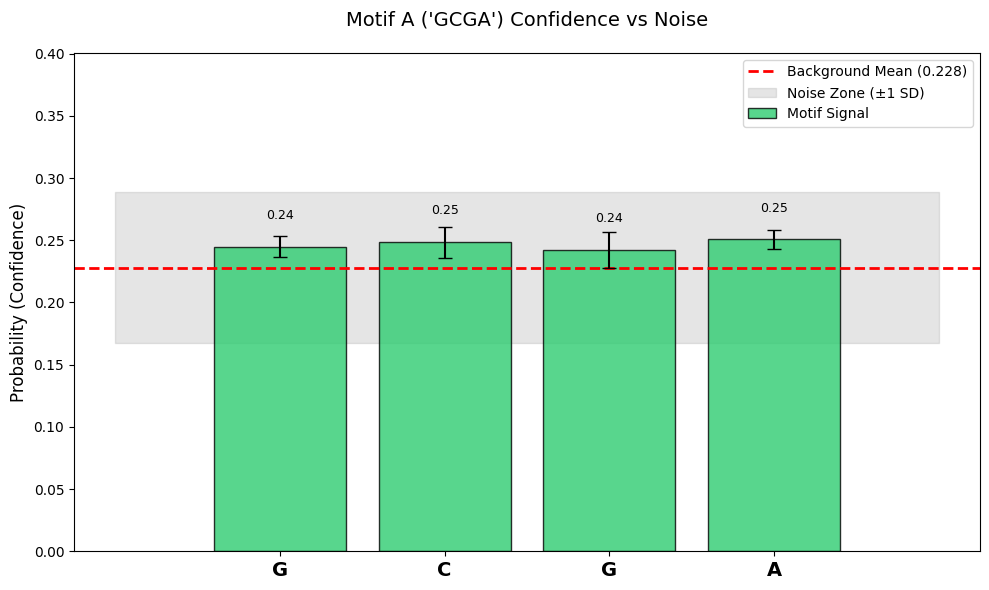

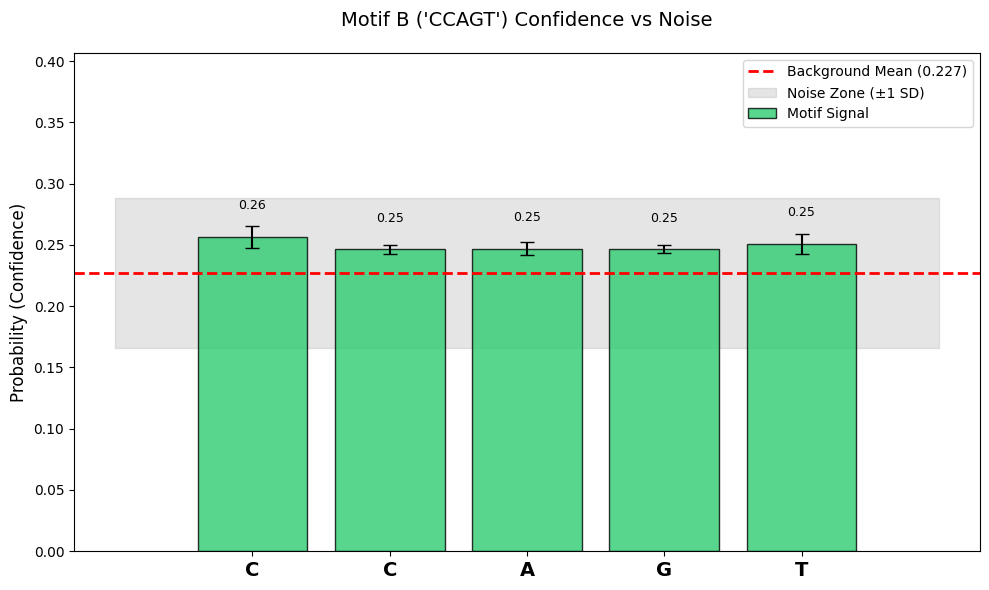

In [13]:
plot_significance_with_noise_floor(df_stats_A, title=f"Motif A ('{MOTIF_A}') Confidence vs Noise")
plot_significance_with_noise_floor(df_stats_B, title=f"Motif B ('{MOTIF_B}') Confidence vs Noise")

In [14]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 58,376
Trainable parameters: 58,376
